In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('Exam_Score_Prediction.csv')

In [ ]:
df

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19997,18,other,bba,6.50,71.3,yes,5.0,good,self-study,low,easy,86.5
19996,19998,18,male,b.com,3.71,41.6,no,5.9,average,coaching,medium,moderate,60.9
19997,19999,19,other,diploma,7.88,68.2,yes,4.6,poor,group study,low,easy,64.5
19998,20000,19,male,bba,4.60,76.3,no,6.1,good,self-study,medium,moderate,79.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


In [ ]:
df.shape

(20000, 13)

### 1. Target Variable Analysis: `exam_score`

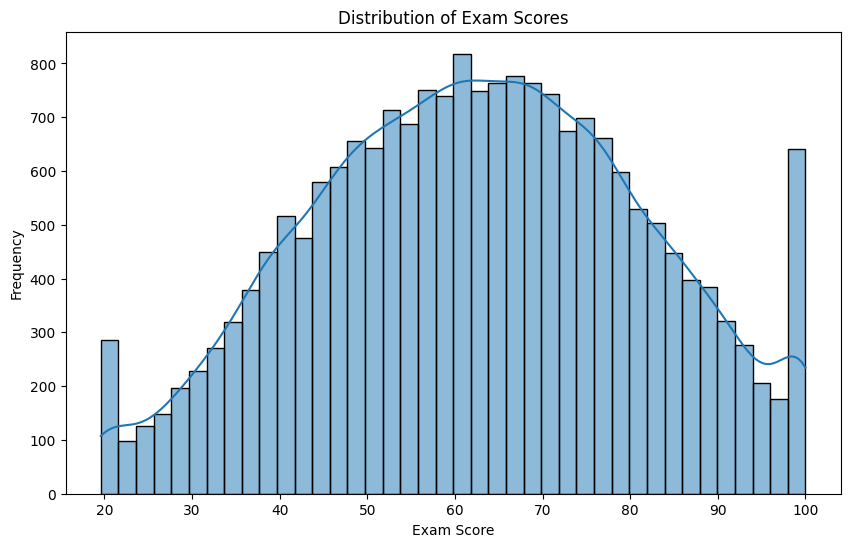

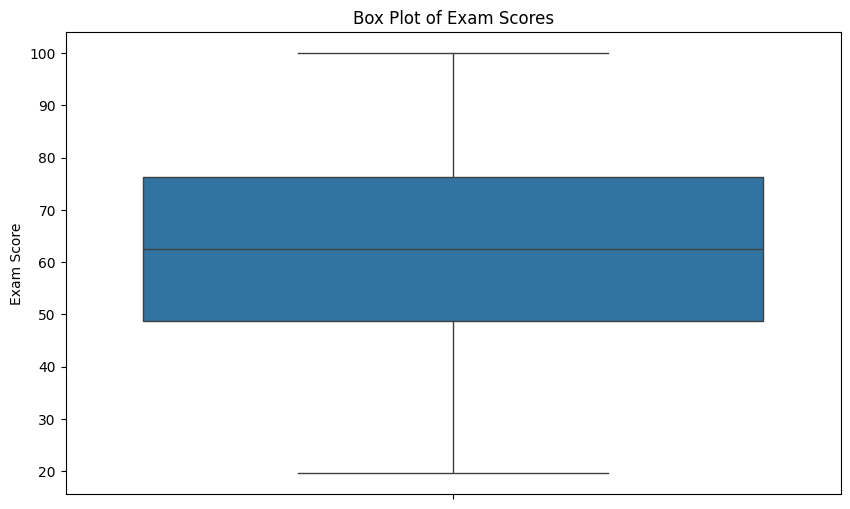

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['exam_score'], kde=True)
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(y=df['exam_score'])
plt.title('Box Plot of Exam Scores')
plt.ylabel('Exam Score')
plt.show()

### 2. Numerical Features vs. `exam_score`

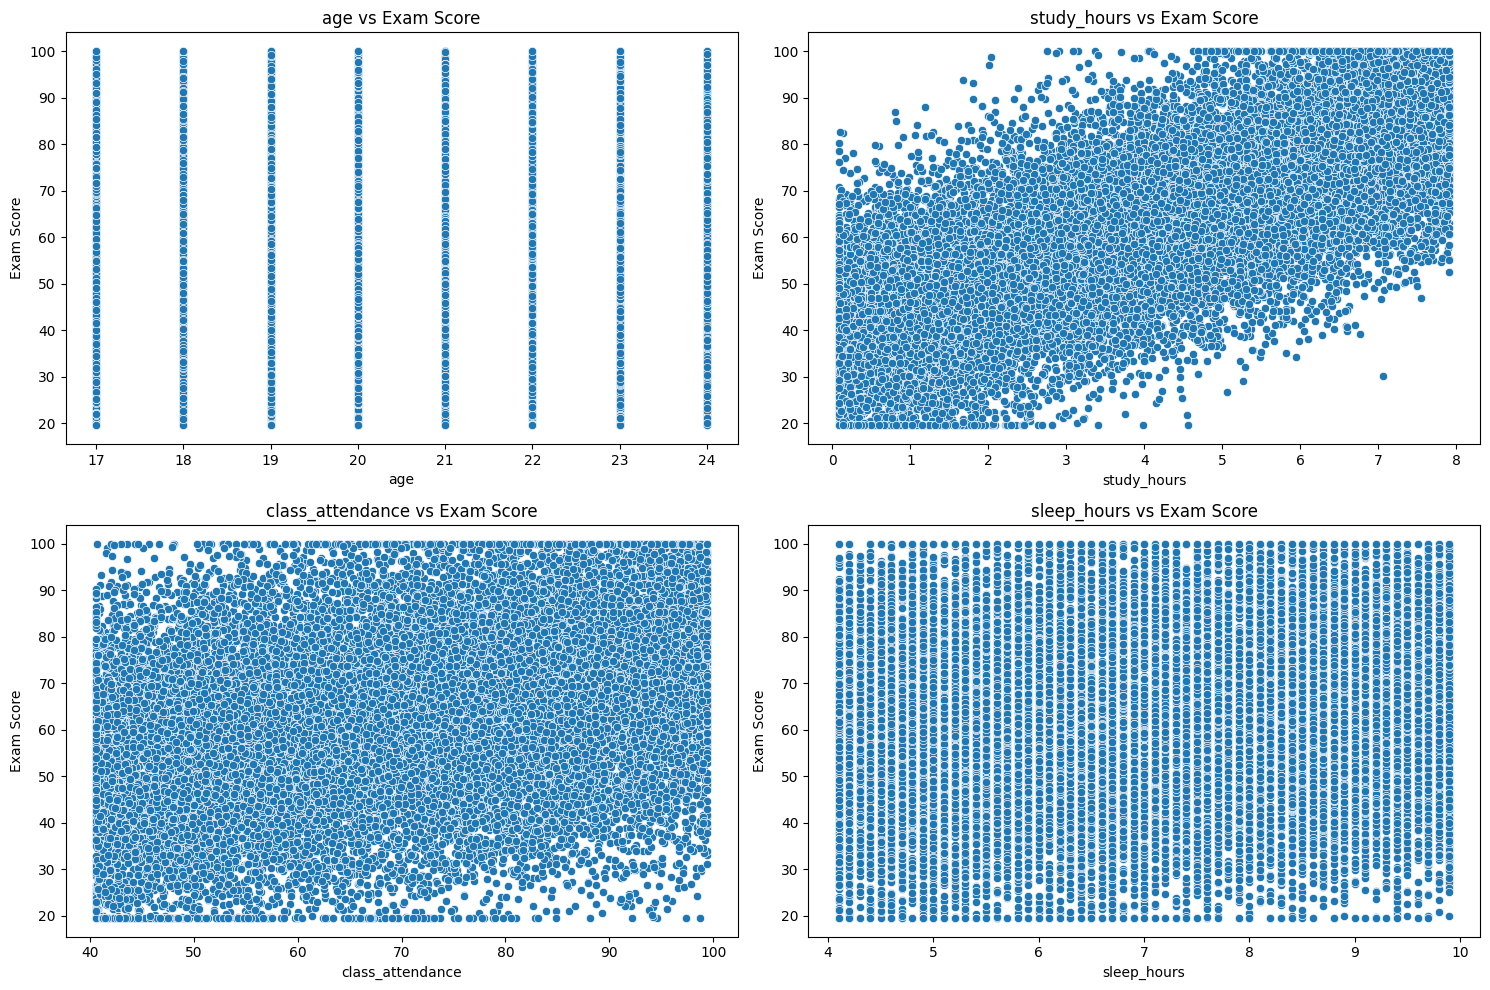

In [ ]:
numerical_features = ['age', 'study_hours', 'class_attendance', 'sleep_hours']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(x=df[feature], y=df['exam_score'])
    plt.title(f'{feature} vs Exam Score')
    plt.xlabel(feature)
    plt.ylabel('Exam Score')
plt.tight_layout()
plt.show()

### 3. Categorical Features vs. `exam_score`

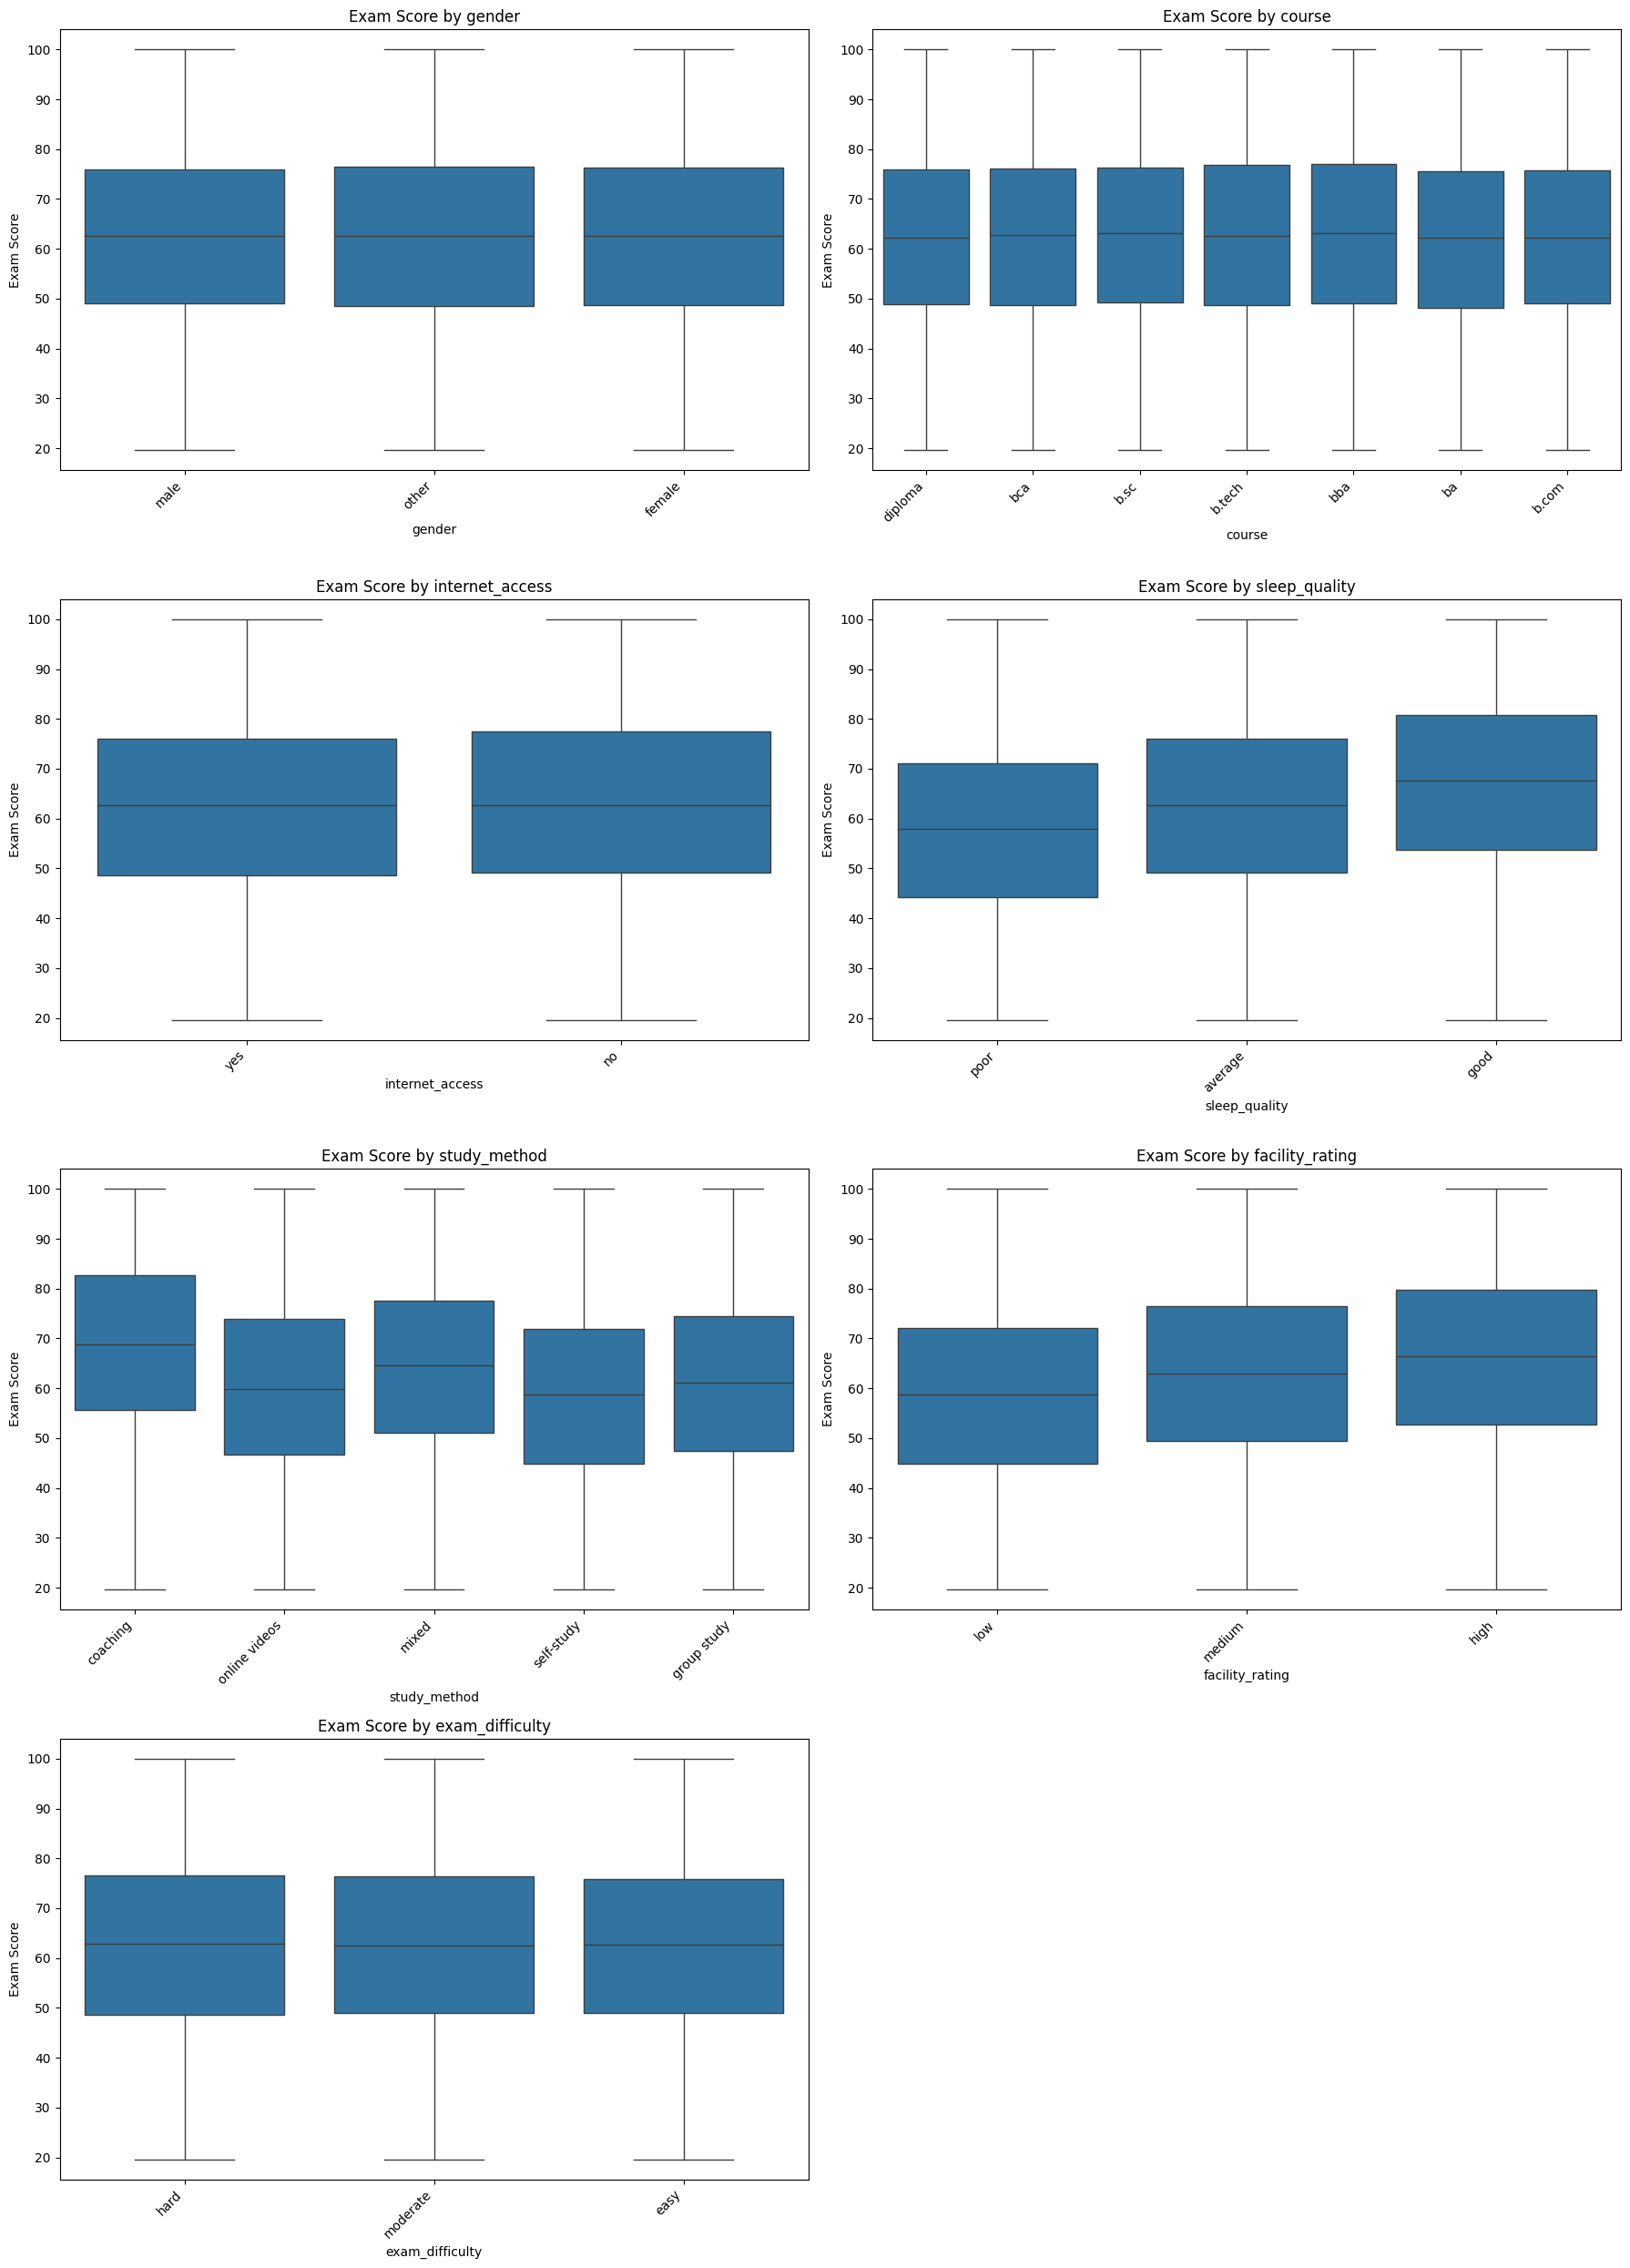

In [ ]:
categorical_features = ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']

plt.figure(figsize=(18, 25))
for i, feature in enumerate(categorical_features):
    plt.subplot(4, 2, i + 1) # Adjust subplot grid as needed
    sns.boxplot(x=df[feature], y=df['exam_score'])
    plt.title(f'Exam Score by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Exam Score')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df=df.drop('student_id',axis=1)

<Axes: >

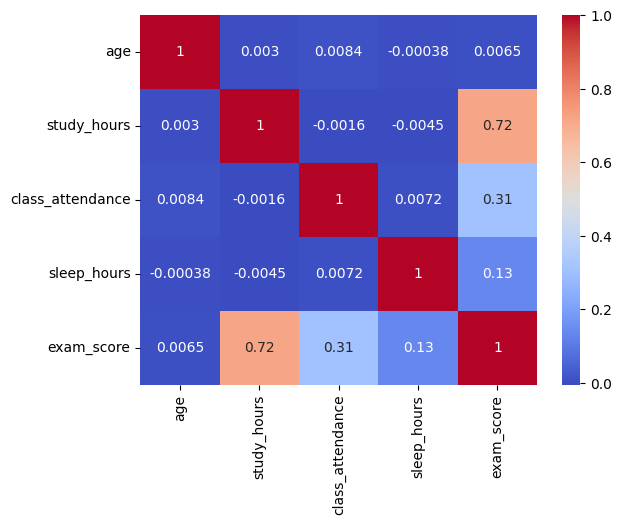

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')

### Statistical Testing: Numerical Features vs. `exam_score`

In [ ]:
from scipy.stats import pearsonr

numerical_features = ['age', 'study_hours', 'class_attendance', 'sleep_hours']

print('Pearson Correlation with Exam Score:')
for feature in numerical_features:
    correlation, p_value = pearsonr(df[feature], df['exam_score'])
    print(f"- {feature}: Correlation = {correlation:.3f}, P-value = {p_value:.3f}")
    if p_value < 0.05:
        print(f"  (Statistically significant relationship between {feature} and exam_score)")
    else:
        print(f"  (No statistically significant relationship between {feature} and exam_score)")

Pearson Correlation with Exam Score:
- age: Correlation = 0.007, P-value = 0.356
  (No statistically significant relationship between age and exam_score)
- study_hours: Correlation = 0.718, P-value = 0.000
  (Statistically significant relationship between study_hours and exam_score)
- class_attendance: Correlation = 0.309, P-value = 0.000
  (Statistically significant relationship between class_attendance and exam_score)
- sleep_hours: Correlation = 0.133, P-value = 0.000
  (Statistically significant relationship between sleep_hours and exam_score)


### Statistical Testing: Categorical Features vs. `exam_score` (ANOVA)

In [ ]:
from scipy.stats import f_oneway

categorical_features = ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']

print('ANOVA Test for Exam Score across Categorical Features:')
for feature in categorical_features:
    groups = [df['exam_score'][df[feature] == category] for category in df[feature].unique()]
    f_statistic, p_value = f_oneway(*groups)
    print(f"- {feature}: F-statistic = {f_statistic:.3f}, P-value = {p_value:.3f}")
    if p_value < 0.05:
        print(f"  (Statistically significant difference in exam_score means across {feature} categories)")
    else:
        print(f"  (No statistically significant difference in exam_score means across {feature} categories)")

ANOVA Test for Exam Score across Categorical Features:
- gender: F-statistic = 0.191, P-value = 0.826
  (No statistically significant difference in exam_score means across gender categories)
- course: F-statistic = 0.614, P-value = 0.719
  (No statistically significant difference in exam_score means across course categories)
- internet_access: F-statistic = 1.225, P-value = 0.268
  (No statistically significant difference in exam_score means across internet_access categories)
- sleep_quality: F-statistic = 411.793, P-value = 0.000
  (Statistically significant difference in exam_score means across sleep_quality categories)
- study_method: F-statistic = 180.527, P-value = 0.000
  (Statistically significant difference in exam_score means across study_method categories)
- facility_rating: F-statistic = 273.766, P-value = 0.000
  (Statistically significant difference in exam_score means across facility_rating categories)
- exam_difficulty: F-statistic = 0.237, P-value = 0.789
  (No statisti

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in categorical_features:
  df[i]=le.fit_transform(df[i])
df

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,1,6,2.78,92.9,1,7.4,2,0,1,1,58.9
1,23,2,5,3.37,64.8,1,4.6,0,3,2,2,54.8
2,22,1,1,7.88,76.8,1,8.5,2,0,0,2,90.3
3,20,2,6,0.67,48.4,1,5.8,0,3,1,2,29.7
4,20,0,6,0.89,71.6,1,9.8,2,0,1,2,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,18,2,4,6.50,71.3,1,5.0,1,4,1,0,86.5
19996,18,1,0,3.71,41.6,0,5.9,0,0,2,2,60.9
19997,19,2,6,7.88,68.2,1,4.6,2,1,1,0,64.5
19998,19,1,4,4.60,76.3,0,6.1,1,4,2,2,79.0


In [ ]:
X=df.drop(['exam_score','age','gender','course','internet_access','exam_difficulty'],axis=1)
Y=df['exam_score']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2,random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor(random_state=42)
dt.fit(X_train,Y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
Y_pred=dt.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score
r2_score(Y_test,Y_pred)

0.39028042924386297

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
adabooster=AdaBoostRegressor(random_state=42)
adabooster.fit(X_train,Y_train)
Y_pred=adabooster.predict(X_test)
r2_score(Y_test,Y_pred)

0.6696005392708153

In [ ]:
from xgboost import XGBRegressor
xgbooster=XGBRegressor()
xgbooster.fit(X_train,Y_train)
Y_pred=xgbooster.predict(X_test)
r2_score(Y_test,Y_pred)

0.6970567541392501

### Hyperparameter Tuning for XGBoost using GridSearchCV

In [60]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Define the parameter grid for XGBoost
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of boosting rounds
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Step size shrinkage to prevent overfitting
    'max_depth': [3, 5, 7],  # Maximum depth of a tree
    'subsample': [0.7, 0.9, 1.0],  # Subsample ratio of the training instance
    'colsample_bytree': [0.7, 0.9, 1.0]  # Subsample ratio of columns when constructing each tree
}

# Initialize XGBRegressor
xgbr = XGBRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=xgbr,
                           param_grid=param_grid,
                           cv=3,  # 3-fold cross-validation
                           scoring='r2',  # Use R-squared for evaluation
                           n_jobs=-1, # Use all available cores
                           verbose=2)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, Y_train)

# Print the best parameters and best R-squared score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best R-squared Score: {grid_search.best_score_:.3f}")

Fitting 3 folds for each of 324 candidates, totalling 972 fits
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.7}
Best R-squared Score: 0.728
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.7}
Best R-squared Score: 0.728


### Train a new XGBoost Model with Best Hyperparameters

In [61]:
# Get the best model from GridSearchCV
best_xgbooster = grid_search.best_estimator_

# Make predictions on the test set with the best model
Y_pred_tuned = best_xgbooster.predict(X_test)

# Evaluate the performance of the tuned model
from sklearn.metrics import r2_score
r2_tuned = r2_score(Y_test, Y_pred_tuned)

print(f"R-squared score of the tuned XGBoost model: {r2_tuned:.3f}")

R-squared score of the tuned XGBoost model: 0.730
